# Pipeline | Carregamento e Detecção de Anomalias [Fase 1 - base_credit]

## Importar dados do Google Drive

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [39]:
# "!"  = avisa o ambiente para rodar o comando no sistema
# "-q" = instala de forma silenciosa, ocultando logs de progresso
!pip -q install plotly
!pip -q install yellowbrick

In [40]:
import pandas as pd # manipulação e análise de dados em tabelas (dataframes)
import numpy as np  # operacoes matemáticas e suporte a matrizes/vetores
import seaborn as sns # criação de gráficos estatísticos com visual
import matplotlib.pyplot as plt # lib base para gerar e customizar gráficos
import plotly.express as px # criação de gráficos interativos

## Importar DataFrame (credit_data.csv)

In [84]:
base_census = pd.read_csv('/content/drive/MyDrive/Documentos/profissional-academico/FATEC/CICLOS/ciclo-v/machine-learning/census.csv')

In [85]:
base_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


## Descrição do DataFrame

In [86]:
base_census.describe()

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Análise exploratórias de anomalias (Alunos)

### Possíveis valores nulos - (Dados nulos em base)
Resultante: Verificação de completude dos dados

In [ ]:
base_census.isnull().sum()

In [ ]:
base_census[base_census.isnull().any(axis=1)]

### Possíveis valores "?" em colunas categóricas - (Dados faltantes disfarçados)
Resultante: Normalização ou remoção

In [ ]:
colunas_categoricas = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

for col in colunas_categoricas:
    qtd = base_census[base_census[col].str.strip() == '?'].shape[0]
    if qtd > 0:
        print(f'{col}: {qtd} registros com "?"')

In [ ]:
base_census[base_census['workclass'].str.strip() == '?']

### Possíveis idades negativas ou fora de faixa - (Incongruências ou Impossibilidades Lógicas)
Resultante: Normalização

In [ ]:
base_census.loc[base_census['age'] < 0]

### Possíveis capital-gain com valor 99999 - (Possível teto/anomalia)
Resultante: Investigação de outliers

In [ ]:
base_census.loc[base_census['capital-gain'] == 99999]

In [ ]:
print(f'Registros com capital-gain = 99999: {base_census[base_census["capital-gain"] == 99999].shape[0]}')
print(f'Total de registros: {base_census.shape[0]}')
print(f'Percentual: {base_census[base_census["capital-gain"] == 99999].shape[0] / base_census.shape[0] * 100:.2f}%')

### Possíveis horas por semana extremas - (Incongruências ou Outliers)
Resultante: Investigação

In [ ]:
base_census.loc[base_census['hour-per-week'] > 80]

### Possíveis valores negativos em colunas numéricas - (Incongruências)
Resultante: Nulos

In [ ]:
colunas_numericas = ['age', 'final-weight', 'education-num', 'capital-gain', 'capital-loos', 'hour-per-week']

for col in colunas_numericas:
    qtd_negativos = base_census[base_census[col] < 0].shape[0]
    print(f'{col}: {qtd_negativos} valores negativos')

# Pipeline | Visualização de Dados e Anomalias [Fase 2 - base_census]

## Eixos de Alvos de Aprendizagem

In [87]:
np.unique(base_census['income'], return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

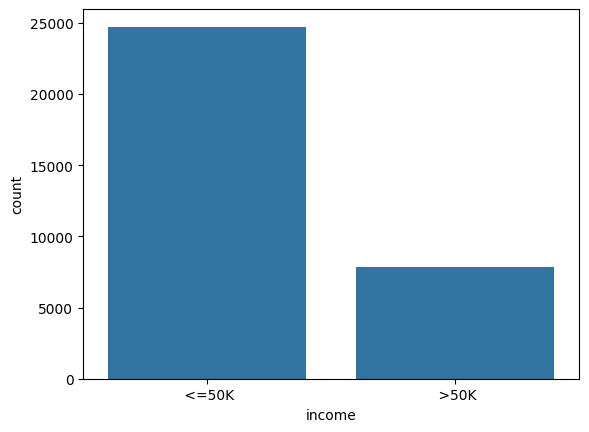

In [88]:
sns.countplot(
    x = base_census['income'],
    hue= base_census['income'],
    palette=['skyblue', 'salmon'],
    legend=True);

## Distribuições das Variáveis Numéricas

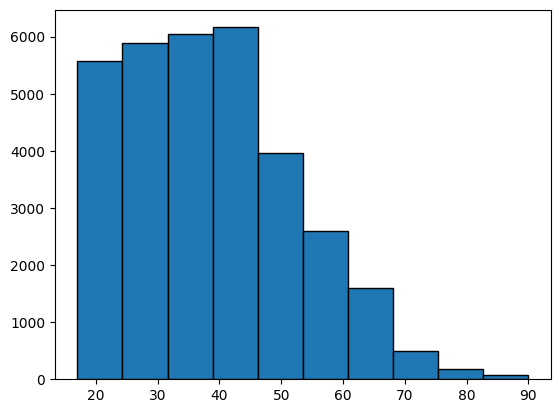

In [90]:
plt.hist(x=base_census['age'], edgecolor='black');

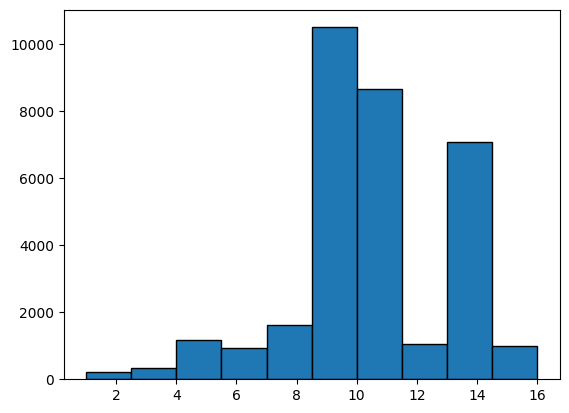

In [92]:
plt.hist(x=base_census['education-num'], edgecolor='black');

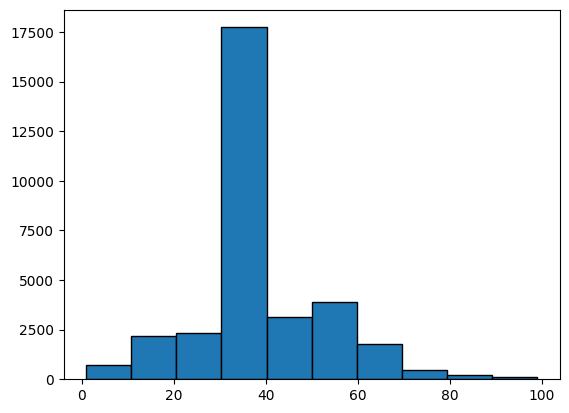

In [93]:
plt.hist(x=base_census['hour-per-week'], edgecolor='black');

### Gráfico detecta área de outliers em capital-gain | Confirmada em Análise

In [ ]:
plt.hist(x=base_census['capital-gain'], edgecolor='black');

In [ ]:
plt.hist(x=base_census['capital-loos'], edgecolor='black');

## Boxplots para Detecção Visual de Outliers

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.boxplot(y=base_census['age'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('age')

sns.boxplot(y=base_census['final-weight'], ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('final-weight')

sns.boxplot(y=base_census['education-num'], ax=axes[0, 2], color='lightgreen')
axes[0, 2].set_title('education-num')

sns.boxplot(y=base_census['capital-gain'], ax=axes[1, 0], color='gold')
axes[1, 0].set_title('capital-gain')

sns.boxplot(y=base_census['capital-loos'], ax=axes[1, 1], color='plum')
axes[1, 1].set_title('capital-loos')

sns.boxplot(y=base_census['hour-per-week'], ax=axes[1, 2], color='lightskyblue')
axes[1, 2].set_title('hour-per-week')

plt.tight_layout()
plt.show()

## Matriz de Dispersão - Correlação entre Variáveis Numéricas

In [ ]:
grafico_census = px.scatter_matrix(base_census, dimensions=['age', 'education-num', 'hour-per-week', 'capital-gain'], color='income')
grafico_census.show()

## Visualização de Dados Faltantes ("?") por Coluna Categórica

In [ ]:
colunas_cat = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
qtd_faltantes = {}

for col in colunas_cat:
    qtd = base_census[base_census[col].str.strip() == '?'].shape[0]
    if qtd > 0:
        qtd_faltantes[col] = qtd

plt.figure(figsize=(10, 5))
plt.bar(qtd_faltantes.keys(), qtd_faltantes.values(), color=['salmon', 'gold', 'plum'], edgecolor='black')
plt.title('Quantidade de registros com "?" por coluna categórica')
plt.ylabel('Quantidade')
plt.xlabel('Coluna')
plt.show()

In [95]:
grafico_grupos = px.treemap(base_census, path=['occupation', 'relationship', 'age'])
grafico_grupos.show()

# Pipeline | Normalização de Dados [Fase 3 - base_credit]

In [55]:
base_credit.mean()

,0
clientid,1000.500000
income,45331.600018
age,40.807559
loan,4444.369695
default,0.141500


In [56]:
base_credit['age'].mean()

np.float64(40.80755937840458)

In [57]:
average_age = base_credit['age'][base_credit['age'] > 0].mean()
print(average_age)

40.92770044906149


In [58]:
# transformando valores de idade negativo na média 40.92770044906149
base_credit.loc[base_credit['age'] < 0, 'age'] = average_age

In [59]:
base_credit[base_credit.isnull().any(axis=1)] # ou base_credit[pd.isnull(base_credit['age'])]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [60]:
base_credit['age'].fillna(base_credit['age'].mean(), inplace=True)

/tmp/ipykernel_4470/1819494362.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [61]:
base_credit.loc[base_credit['clientid'].isin([29, 31, 32])]

,clientid,income,age,loan,default
28,29,59417.805406,40.9277,2082.625938,0
30,31,48528.852796,40.9277,6155.784670,0
31,32,23526.302555,40.9277,2862.010139,0


In [62]:
type(base_credit)

pandas.core.frame.DataFrame

# Pipeline | Previsores e Classes Neurais [Fase 4 - base_credit]

## Vetores Neurais de Classes

In [63]:
x_credit = base_credit.iloc[:, 1:4].values # transforma as colunas income, age e loan em um vetor de vetores
x_credit

array([[6.61559251e+04, 5.90170151e+01, 8.10653213e+03],
       [3.44151540e+04, 4.81171531e+01, 6.56474502e+03],
       [5.73171701e+04, 6.31080495e+01, 8.02095330e+03],
       ...,
       [4.43114493e+04, 2.80171669e+01, 5.52278669e+03],
       [4.37560566e+04, 6.39717958e+01, 1.62272260e+03],
       [6.94365796e+04, 5.61526170e+01, 7.37883360e+03]])

In [64]:
type(x_credit)

numpy.ndarray

In [65]:
y_credit = base_credit.iloc[:, 4].values # transforma a coluna default em um vetor
y_credit

array([0, 0, 0, ..., 1, 0, 0])

In [66]:
type(y_credit)

numpy.ndarray

## Organização de Escalas de Digestão

In [67]:
# menores valores das colunas do eixo x
x_credit[:, 0].min(), x_credit[:, 1].min(), x_credit[:, 2].min()

(np.float64(20014.4894700497),
 np.float64(18.055188510566897),
 np.float64(1.37762959325451))

In [68]:
# maiores valores das colunas do eixo x
x_credit[:, 0].max(), x_credit[:, 1].max(), x_credit[:, 2].max()

(np.float64(69995.6855783239),
 np.float64(63.971795841120205),
 np.float64(13766.0512393337))

In [69]:
# diferença entre os maiores e menores valores das colunas do eixo x
x_credit[:, 0].max() - x_credit[:, 0].min(), x_credit[:, 1].max() - x_credit[:, 1].min(), x_credit[:, 2].max() - x_credit[:, 2].min()

(np.float64(49981.196108274205),
 np.float64(45.916607330553305),
 np.float64(13764.673609740445))

In [70]:
# importa a classe StandardScaler, que serve para normalizar variáveis numéricas
from sklearn.preprocessing import StandardScaler
scaler_credit = StandardScaler()

# fit: aprende média e desvio padrão de cada coluna
# transform: aplica a fórmula (x - média) / desvio padrão
# resultado: dados com média ~0 e desvio padrão ~1
x_credit = scaler_credit.fit_transform(x_credit)

In [71]:
from sklearn.model_selection import train_test_split

In [74]:
# divide os dados em:
# x_credit_treinamento -> dados de entrada para treino
# x_credit_teste -> dados de entrada para teste
# y_credit_treinamento -> respostas (rótulos) para treino
# y_credit_teste -> respostas (rótulos) para teste
# test_size=0.15 -> 15% dos dados serão usados para teste
# random_state=0 -> garante que a divisão seja sempre a mesma (reprodutibilidade)
x_credit_treinamento, x_credit_teste, y_credit_treinamento, y_credit_teste = train_test_split(x_credit, y_credit, test_size=0.15, random_state=0)

In [77]:
# importa a biblioteca para salvar dados em arquivo
import pickle

# abre (ou cria) um arquivo no modo escrita binária ('wb')
with open('/content/drive/MyDrive/Documentos/profissional-academico/FATEC/CICLOS/ciclo-v/machine-learning/credit.pkt', mode = 'wb') as f:

  # salva (serializa) os dados de treino e teste no arquivo
  # isso permite carregar depois sem precisar processar tudo novamente
  pickle.dump([x_credit_treinamento, y_credit_treinamento, x_credit_teste, y_credit_teste], f)